TensorFlow version: 2.19.0


Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
704/704 - 11s - 15ms/step - accuracy: 0.4225 - loss: 1.6484 - val_accuracy: 0.4896 - val_loss: 1.4972 - learning_rate: 1.0000e-03
Epoch 2/30
704/704 - 10s - 14ms/step - accuracy: 0.5261 - loss: 1.3253 - val_accuracy: 0.6008 - val_loss: 1.1160 - learning_rate: 1.0000e-03
Epoch 3/30
704/704 - 8s - 11ms/step - accuracy: 0.5816 - loss: 1.1838 - val_accuracy: 0.5910 - val_loss: 1.1749 - learning_rate: 1.0000e-03
Epoch 4/30
704/704 - 8s - 11ms/step - accuracy: 0.6122 - loss: 1.0974 - val_accuracy: 0.6382 - val_loss: 1.0545 - learning_rate: 1.0000e-03
Epoch 5/30
704/704 - 7s - 10ms/step - accuracy: 0.6405 - loss: 1.0286 - val_accuracy: 0.6556 - val_loss: 1.0200 - learning_rate: 1.0000e-03
Epoch 6/30
704/704 - 8s - 11ms/step - accuracy: 0.6566 - loss: 0.9812 - val_accuracy: 0.6628 - val_loss: 0.9664 - learning_rate: 1.0000e-03
Epoch 7/30
704/704 - 7s - 11ms/step - accuracy: 0.6726 - loss: 0.9434 - val_accuracy: 0.7230 - val_loss: 0.7999 - learning_rate: 1.0000e-03
Epoch 8/30
704/704

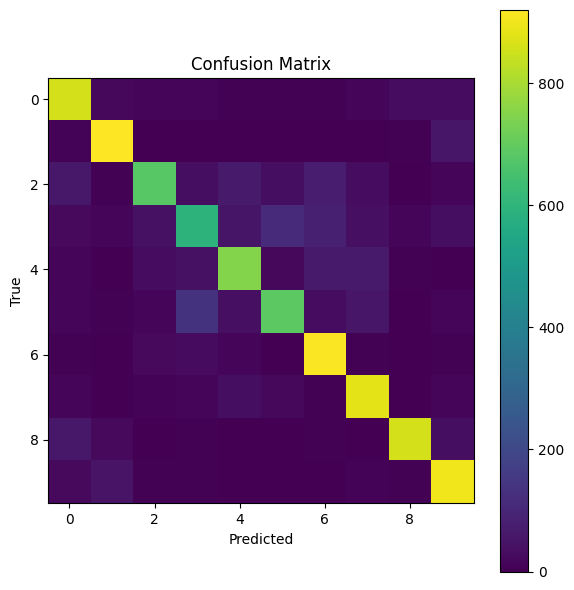

In [2]:
# --- Setup (uses installed TF >=2.18)
import tensorflow as tf, numpy as np, random, os
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
np.random.seed(42); random.seed(42); tf.random.set_seed(42)

# --- Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten(); y_test = y_test.flatten()
num_classes = 10

# --- Preprocess
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Validation split
val_ratio = 0.1
n_val = int(len(x_train) * val_ratio)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_train, y_train = x_train[n_val:], y_train[n_val:]

# --- Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# --- Model
def make_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cnn_classifier")

model = make_cnn()
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

# --- Train
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30, batch_size=64, callbacks=callbacks, verbose=2
)

# --- Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# --- Report + Confusion Matrix
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
cifar10_names = ["airplane","automobile","bird","cat","deer",
                 "dog","frog","horse","ship","truck"]
print(classification_report(y_test, y_pred, target_names=cifar10_names))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- Save (Keras 3 format)
model.save("cnn_model.keras")
np.savez("cnn_metrics_cifar10.npz", test_acc=test_acc)

